# Spam detector 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

from wordcloud import WordCloud

## Get the Data 

In [7]:
#https://www.kaggle.com/uciml/sms-spam-collection-dataset
url='https://drive.google.com/file/d/1b5p4CJMDpOzkmQIi5Jk9PLxD8reHzj6S/view?usp=sharing'
url_='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url_)

In [8]:
df.shape

(5572, 2)

In [9]:
df.head()

,text,target
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [10]:
df.columns

Index(['text', 'target'], dtype='object')

In [11]:
from collections import Counter
Counter( df['target'])

Counter({'ham': 4825, 'spam': 747})

## Visualization 

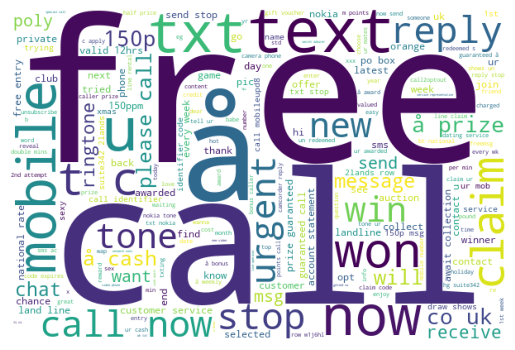

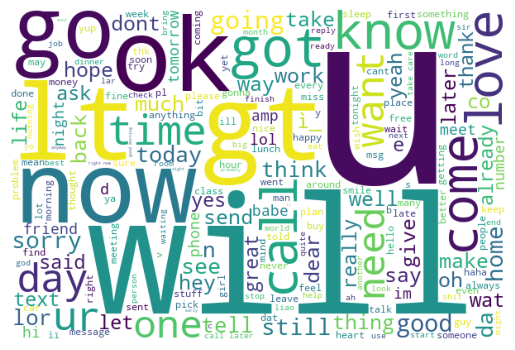

In [12]:
def visualize(label):
    text = ''
    for msg in df[df['target'] == label]['text']:
        msg = msg.lower()
        text += msg + ' '
    wordcloud = WordCloud(width=600, height=400, background_color="white").generate(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

visualize('spam')
visualize('ham')

## Train Test Split

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.20)

In [14]:
print(X_train.shape, y_train.shape)

(4457,) (4457,)


## Vectorization

In [15]:
vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

## Model

In [16]:
clf = MultinomialNB(alpha=0.1)
clf.fit(X_train_transformed, y_train)
y_pred = clf.predict(X_test_transformed)

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       973
        spam       0.96      0.94      0.95       142

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [18]:
print(confusion_matrix(y_test, y_pred))

[[968   5]
 [  9 133]]


В останньому ноутбуці по кроках будується простий детектор спаму для SMS‑повідомлень на основі наївного баєсівського класифікатора. Спочатку з Google Drive завантажується датасет SMS Spam Coll, де кожен рядок має мітку spam або ham та текст повідомлення. 

Потім досліджується розмір таблиці, кілька перших рядків і розподіл класів за допомогою Counter, щоб побачити дисбаланс між спамом і нормальними повідомленнями. Далі для кожного класу будується wordcloud. Функція visualize(label) збирає всі тексти з даною міткою, приводить їх до нижнього регістру, об’єднує в один великий рядок і генерує хмару слів, яка наочно показує найчастіші терміни окремо для спаму й хему.

Після візуалізації дані діляться на тренувальну й тестову вибірки за допомогою train_test_split, де вхідними ознаками є сирі тексти, а ціллю — мітка target; розміри підмножин виводяться для контролю. Далі йде перетворення тексту в числові ознаки через CountVectorizer, який будує словник усіх токенів і формує розріджені матриці частот слів для train і test. 

In [19]:
#Наприклад: 

def predict_message(msg, vectorizer, model):
    #Проста перевірка одного повідомлення.
    #Повертає чи спам чи не спам повідомлення) та ймовірність спаму.
    X_vec = vectorizer.transform([msg]) #перетворити текст у вектори
    proba = model.predict_proba(X_vec)[0]#ймовірності класів
    label = model.predict(X_vec)[0]# передбачена мітка
    #порядок класів такий: спам не спам
    spam_proba = proba[list(model.classes_).index('spam')]
    return label, spam_proba
#так як модель вже натренерована, перевірю:

In [21]:
msg = "Congratulations! You have won a free ticket. Call now!" #-Повідомлення явно якесь рекламне
label, p_spam = predict_message(msg, vectorizer, clf)
print(label, f"(P(spam) = {p_spam:.2f})")

#Ось алгоритм правильно визначив повідомлення


spam (P(spam) = 1.00)
